# Лабораторная работа №1

## Базовый конвейер ML: от данных до модели классификации

### **Задание: Построить и сравнить три модели для прогнозирования оттока клиентов телеком-компании.**

**Импорты нужных библиотек**

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

**Разбор данных**

In [59]:
df = pd.read_csv('telecom_churn.csv')

print("Информация о датасете:")
df.info()

print("\nПроверка на наличие пропусков:")
print(df.isnull().sum())

print("\nРаспределение целевой переменной Churn:")
print(df['Churn'].value_counts())

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charg

**Подготовка данных к обучению**

In [60]:
X = df.drop('Churn', axis=1)
Y = df['Churn']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

**Обучение и проверка модели**

In [61]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Neighbors': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )
    
    pipeline.fit(X_train, Y_train)
    Y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(Y_test, Y_pred)
    results[name] = acc
    print(f"Accuracy ({name}): {acc:.4f}")

Accuracy (Logistic Regression): 0.8573
Accuracy (Decision Tree): 0.9161
Accuracy (K-Neighbors): 0.8885


**Анализ результатов**

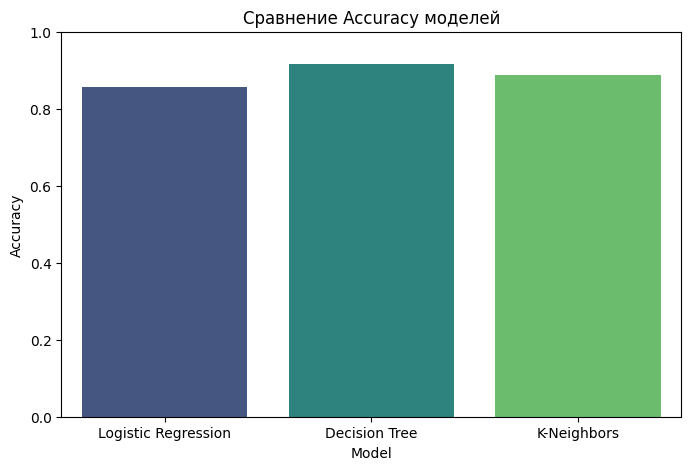


Наилучшая модель: Decision Tree

Матрица ошибок для лучшей модели:
[[672  37]
 [ 32  93]]

Ошибочно предсказаны как ушедшие (False Positives): 37
Ошибочно предсказаны как лояльные (False Negatives): 32


In [62]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Сравнение Accuracy моделей')
plt.ylim(0, 1)
plt.show()

best_model_name = max(results, key=results.get)
print(f"\nНаилучшая модель: {best_model_name}")

best_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', models[best_model_name])
    ]
)
best_pipeline.fit(X_train, Y_train)
Y_pred_best = best_pipeline.predict(X_test)

conf_matrix = confusion_matrix(Y_test, Y_pred_best)
print("\nМатрица ошибок для лучшей модели:")
print(conf_matrix)

false_positives = conf_matrix[0, 1]
false_negatives = conf_matrix[1, 0]

print(f"\nОшибочно предсказаны как ушедшие (False Positives): {false_positives}")
print(f"Ошибочно предсказаны как лояльные (False Negatives): {false_negatives}")